# Mini Project – EDA (EnTC A3 Group 1)
## Title: Analysis on Student Daily Commute
### Dataset: Collected via Google Forms from various students
### Subject: Exploratory Data Analysis (Sem 2 – B.Tech)
---
#### Members:

*   Tanmay Agarwal (25070123158)
*   Tannishtha Gupta (25070123049)


---
This notebook performs a complete EDA on our student commute dataset.  
Techniques covered:
1. Dataset Loading & Inspection
2. Dataset Shape, Head, Tail, Info, dtypes
3. Descriptive Statistics (describe)
4. Missing Value Analysis (isnull, fillna, dropna)
5. Frequency Count (value_counts)
6. Unique Values (unique, nunique)
7. Percentage Distribution
8. Filtering Data
9. Cross Tabulation (pd.crosstab)
10. Grouping Data (groupby)
11. Sorting
12. Adding a Derived Column


## Step 1 – Import Libraries and Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/student_commute_data_google_form.csv')

# Rename columns for easier access
df.columns = ['Timestamp', 'Starting_Point', 'Destination',
              'Primary_Mode', 'Secondary_Mode', 'Time_of_Day',
              'Travel_Time_min', 'One_Way_Cost_INR',
              'Delay_Points', 'Satisfaction']

print("Dataset loaded successfully!")
print(df)


Dataset loaded successfully!
          Timestamp     Starting_Point   Destination          Primary_Mode  \
0     3/7/2026 9:02              Other       Kharadi                 Metro   
1     3/7/2026 9:08            Kothrud  Pune Station                 Metro   
2     3/7/2026 9:10             Pashan   Viman Nagar  Personal Two-Wheeler   
3     3/7/2026 9:15              Wakad       Kharadi                 Metro   
4     3/7/2026 9:52  SIT Lavale Campus      Swargate               Carpool   
..              ...                ...           ...                   ...   
719  3/14/2026 7:41            Kothrud      Swargate                 Metro   
720  3/14/2026 7:59              Baner  Pune Station        Cab (Ola/Uber)   
721  3/14/2026 8:03            Kothrud  Pune Station               Carpool   
722  3/14/2026 8:20       Shivajinagar     Hinjewadi        PMPML City Bus   
723  3/14/2026 8:29            Kothrud   Viman Nagar        Cab (Ola/Uber)   

         Secondary_Mode           

## Step 2 – Basic Dataset Inspection

In [2]:
# Shape: (rows, columns)
print("Shape of the dataset:")
print(df.shape)


Shape of the dataset:
(724, 10)


In [3]:
# First 5 rows
print("First 5 rows (head):")
print(df.head())


First 5 rows (head):
       Timestamp     Starting_Point   Destination          Primary_Mode  \
0  3/7/2026 9:02              Other       Kharadi                 Metro   
1  3/7/2026 9:08            Kothrud  Pune Station                 Metro   
2  3/7/2026 9:10             Pashan   Viman Nagar  Personal Two-Wheeler   
3  3/7/2026 9:15              Wakad       Kharadi                 Metro   
4  3/7/2026 9:52  SIT Lavale Campus      Swargate               Carpool   

   Secondary_Mode                  Time_of_Day  Travel_Time_min  \
0  PMPML City Bus  Morning Peak (8 AM - 11 AM)               41   
1  PMPML City Bus           Night (After 8 PM)               54   
2  PMPML City Bus  Morning Peak (8 AM - 11 AM)               45   
3           Metro   Evening Peak (4 PM - 8 PM)               33   
4           Metro  Morning Peak (8 AM - 11 AM)               57   

   One_Way_Cost_INR       Delay_Points  Satisfaction  
0                27      Chandni Chowk             2  
1              

In [4]:
# Last 5 rows
print("Last 5 rows (tail):")
print(df.tail())


Last 5 rows (tail):
          Timestamp Starting_Point   Destination    Primary_Mode  \
719  3/14/2026 7:41        Kothrud      Swargate           Metro   
720  3/14/2026 7:59          Baner  Pune Station  Cab (Ola/Uber)   
721  3/14/2026 8:03        Kothrud  Pune Station         Carpool   
722  3/14/2026 8:20   Shivajinagar     Hinjewadi  PMPML City Bus   
723  3/14/2026 8:29        Kothrud   Viman Nagar  Cab (Ola/Uber)   

         Secondary_Mode                  Time_of_Day  Travel_Time_min  \
719      PMPML City Bus  Morning Peak (8 AM - 11 AM)               36   
720  None (Direct Trip)           Night (After 8 PM)               79   
721             Walking           Night (After 8 PM)               29   
722               Metro           Night (After 8 PM)              111   
723               Metro        Midday (11 AM - 4 PM)               65   

     One_Way_Cost_INR                     Delay_Points  Satisfaction  
719                33  Yerawada/Kalyani Nagar junction       

In [5]:
# Data types of each column
print("Data types of each column:")
print(df.dtypes)


Data types of each column:
Timestamp           object
Starting_Point      object
Destination         object
Primary_Mode        object
Secondary_Mode      object
Time_of_Day         object
Travel_Time_min      int64
One_Way_Cost_INR     int64
Delay_Points        object
Satisfaction         int64
dtype: object


In [6]:
# General info about the DataFrame
print("General Info:")
df.info()


General Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Timestamp         724 non-null    object
 1   Starting_Point    724 non-null    object
 2   Destination       724 non-null    object
 3   Primary_Mode      724 non-null    object
 4   Secondary_Mode    724 non-null    object
 5   Time_of_Day       724 non-null    object
 6   Travel_Time_min   724 non-null    int64 
 7   One_Way_Cost_INR  724 non-null    int64 
 8   Delay_Points      592 non-null    object
 9   Satisfaction      724 non-null    int64 
dtypes: int64(3), object(7)
memory usage: 56.7+ KB


In [7]:
# Column names
print("Column names:")
print(df.columns.tolist())


Column names:
['Timestamp', 'Starting_Point', 'Destination', 'Primary_Mode', 'Secondary_Mode', 'Time_of_Day', 'Travel_Time_min', 'One_Way_Cost_INR', 'Delay_Points', 'Satisfaction']


## Step 3 – Descriptive Statistics

In [8]:
# Summary statistics for numerical columns
print("Descriptive Statistics:")
print(df.describe())


Descriptive Statistics:
       Travel_Time_min  One_Way_Cost_INR  Satisfaction
count       724.000000        724.000000    724.000000
mean         57.468232        126.998619      2.982044
std          22.032676        126.113261      1.483317
min          20.000000         10.000000      1.000000
25%          40.000000         33.000000      2.000000
50%          54.000000         65.500000      3.000000
75%          72.000000        210.000000      4.000000
max         119.000000        445.000000      5.000000


In [10]:
# Individual stats for Travel_Time_min
print("Mean Travel Time (min):", df['Travel_Time_min'].mean().round(2))
print("Median Travel Time (min):", df['Travel_Time_min'].median())
print("Std Dev of Travel Time:", df['Travel_Time_min'].std(),2)
print("Min Travel Time:", df['Travel_Time_min'].min())
print("Max Travel Time:", df['Travel_Time_min'].max())


Mean Travel Time (min): 57.47
Median Travel Time (min): 54.0
Std Dev of Travel Time: 22.03267626562935 2
Min Travel Time: 20
Max Travel Time: 119


In [12]:
# Individual stats for One_Way_Cost_INR
print("Mean One-Way Cost (₹):", df['One_Way_Cost_INR'].mean().round(2))
print("Median One-Way Cost (₹):", df['One_Way_Cost_INR'].median())
print("Std Dev of Cost:", df['One_Way_Cost_INR'].std(),2)
print("Min Cost (₹):", df['One_Way_Cost_INR'].min())
print("Max Cost (₹):", df['One_Way_Cost_INR'].max())


Mean One-Way Cost (₹): 127.0
Median One-Way Cost (₹): 65.5
Std Dev of Cost: 126.11326112491602 2
Min Cost (₹): 10
Max Cost (₹): 445


## Step 4 – Missing Value Analysis

In [13]:
# Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Timestamp             0
Starting_Point        0
Destination           0
Primary_Mode          0
Secondary_Mode        0
Time_of_Day           0
Travel_Time_min       0
One_Way_Cost_INR      0
Delay_Points        132
Satisfaction          0
dtype: int64


In [14]:
# Percentage of missing values
print("Percentage of missing values per column:")
print((df.isnull().sum() / len(df) * 100).round(2))


Percentage of missing values per column:
Timestamp            0.00
Starting_Point       0.00
Destination          0.00
Primary_Mode         0.00
Secondary_Mode       0.00
Time_of_Day          0.00
Travel_Time_min      0.00
One_Way_Cost_INR     0.00
Delay_Points        18.23
Satisfaction         0.00
dtype: float64


In [15]:
# Fill missing Delay_Points with 'None'
df['Delay_Points'] = df['Delay_Points'].fillna('None')
print("Missing values after filling:")
print(df.isnull().sum())


Missing values after filling:
Timestamp           0
Starting_Point      0
Destination         0
Primary_Mode        0
Secondary_Mode      0
Time_of_Day         0
Travel_Time_min     0
One_Way_Cost_INR    0
Delay_Points        0
Satisfaction        0
dtype: int64


## Step 5 – Frequency Count (value_counts)

In [16]:
# Count of each Primary Mode of Transport
print("Frequency Count – Primary Mode of Transport:")
print(df['Primary_Mode'].value_counts())


Frequency Count – Primary Mode of Transport:
Primary_Mode
Metro                   131
Carpool                 130
PMPML City Bus          129
Cab (Ola/Uber)          121
Auto Rickshaw           115
Personal Two-Wheeler     98
Name: count, dtype: int64


In [17]:
# Count of each Time of Day
print("Frequency Count – Time of Day:")
print(df['Time_of_Day'].value_counts())


Frequency Count – Time of Day:
Time_of_Day
Midday (11 AM - 4 PM)          205
Night (After 8 PM)             177
Morning Peak (8 AM - 11 AM)    174
Evening Peak (4 PM - 8 PM)     168
Name: count, dtype: int64


In [18]:
# Count of each Starting Point
print("Frequency Count – Starting Point:")
print(df['Starting_Point'].value_counts())


Frequency Count – Starting Point:
Starting_Point
Kothrud              129
SIT Lavale Campus    112
Shivajinagar         109
Baner                101
Wakad                 95
Pashan                89
Other                 89
Name: count, dtype: int64


In [19]:
# Count of each Destination
print("Frequency Count – Destination:")
print(df['Destination'].value_counts())


Frequency Count – Destination:
Destination
Swargate        131
Viman Nagar     131
Kharadi         127
Pune Station    126
Hinjewadi       113
Other            96
Name: count, dtype: int64


In [20]:
# Count of each Delay Point
print("Frequency Count – Delay Points / Bottlenecks:")
print(df['Delay_Points'].value_counts())


Frequency Count – Delay Points / Bottlenecks:
Delay_Points
Waiting for Bus/Metro              133
None                               132
Hinjewadi Traffic                  127
Yerawada/Kalyani Nagar junction    114
Chandni Chowk                      110
University Circle                  108
Name: count, dtype: int64


In [21]:
# Count of Satisfaction scores
print("Frequency Count – Satisfaction Rating:")
print(df['Satisfaction'].value_counts().sort_index())


Frequency Count – Satisfaction Rating:
Satisfaction
1    166
2    139
3    126
4    128
5    165
Name: count, dtype: int64


## Step 6 – Unique Values (unique & nunique)

In [22]:
# Unique values in each categorical column
print("Unique Starting Points:")
print(df['Starting_Point'].unique())
print()
print("Unique Destinations:")
print(df['Destination'].unique())
print()
print("Unique Primary Modes:")
print(df['Primary_Mode'].unique())
print()
print("Unique Time of Day:")
print(df['Time_of_Day'].unique())
print()
print("Unique Delay Points:")
print(df['Delay_Points'].unique())


Unique Starting Points:
['Other' 'Kothrud' 'Pashan' 'Wakad' 'SIT Lavale Campus' 'Shivajinagar'
 'Baner']

Unique Destinations:
['Kharadi' 'Pune Station' 'Viman Nagar' 'Swargate' 'Hinjewadi' 'Other']

Unique Primary Modes:
['Metro' 'Personal Two-Wheeler' 'Carpool' 'Cab (Ola/Uber)'
 'PMPML City Bus' 'Auto Rickshaw']

Unique Time of Day:
['Morning Peak (8 AM - 11 AM)' 'Night (After 8 PM)'
 'Evening Peak (4 PM - 8 PM)' 'Midday (11 AM - 4 PM)']

Unique Delay Points:
['Chandni Chowk' 'Hinjewadi Traffic' 'None' 'University Circle'
 'Yerawada/Kalyani Nagar junction' 'Waiting for Bus/Metro']


In [23]:
# Number of unique values in each column
print("Number of unique values per column (nunique):")
print(df.nunique())


Number of unique values per column (nunique):
Timestamp           709
Starting_Point        7
Destination           6
Primary_Mode          6
Secondary_Mode        6
Time_of_Day           4
Travel_Time_min      92
One_Way_Cost_INR    249
Delay_Points          6
Satisfaction          5
dtype: int64


## Step 7 – Percentage Distribution

In [24]:
# Percentage distribution of Primary Mode
print("Percentage Distribution – Primary Mode of Transport:")
print((df['Primary_Mode'].value_counts(normalize=True) * 100).round(2))


Percentage Distribution – Primary Mode of Transport:
Primary_Mode
Metro                   18.09
Carpool                 17.96
PMPML City Bus          17.82
Cab (Ola/Uber)          16.71
Auto Rickshaw           15.88
Personal Two-Wheeler    13.54
Name: proportion, dtype: float64


In [25]:
# Percentage distribution of Time of Day
print("Percentage Distribution – Time of Day:")
print((df['Time_of_Day'].value_counts(normalize=True) * 100).round(2))


Percentage Distribution – Time of Day:
Time_of_Day
Midday (11 AM - 4 PM)          28.31
Night (After 8 PM)             24.45
Morning Peak (8 AM - 11 AM)    24.03
Evening Peak (4 PM - 8 PM)     23.20
Name: proportion, dtype: float64


In [26]:
# Percentage distribution of Satisfaction
print("Percentage Distribution – Satisfaction Rating:")
print((df['Satisfaction'].value_counts(normalize=True).sort_index() * 100).round(2))


Percentage Distribution – Satisfaction Rating:
Satisfaction
1    22.93
2    19.20
3    17.40
4    17.68
5    22.79
Name: proportion, dtype: float64


In [27]:
# Percentage distribution of Delay Points
print("Percentage Distribution – Delay Points:")
print((df['Delay_Points'].value_counts(normalize=True) * 100).round(2))


Percentage Distribution – Delay Points:
Delay_Points
Waiting for Bus/Metro              18.37
None                               18.23
Hinjewadi Traffic                  17.54
Yerawada/Kalyani Nagar junction    15.75
Chandni Chowk                      15.19
University Circle                  14.92
Name: proportion, dtype: float64


## Step 8 – Filtering Data

In [28]:
# Filter: Students who use Metro as Primary Mode
metro_commuters = df[df['Primary_Mode'] == 'Metro']
print("Students using Metro as Primary Mode:")
print(metro_commuters)


Students using Metro as Primary Mode:
           Timestamp     Starting_Point   Destination Primary_Mode  \
0      3/7/2026 9:02              Other       Kharadi        Metro   
1      3/7/2026 9:08            Kothrud  Pune Station        Metro   
3      3/7/2026 9:15              Wakad       Kharadi        Metro   
6     3/7/2026 10:40  SIT Lavale Campus  Pune Station        Metro   
8     3/7/2026 10:51              Other       Kharadi        Metro   
..               ...                ...           ...          ...   
688  3/13/2026 23:34              Other      Swargate        Metro   
695   3/14/2026 1:29  SIT Lavale Campus  Pune Station        Metro   
698   3/14/2026 2:12              Wakad       Kharadi        Metro   
714   3/14/2026 6:26  SIT Lavale Campus      Swargate        Metro   
719   3/14/2026 7:41            Kothrud      Swargate        Metro   

         Secondary_Mode                  Time_of_Day  Travel_Time_min  \
0        PMPML City Bus  Morning Peak (8 AM - 11

In [29]:
# Filter: Commutes during Morning Peak hours
morning_commuters = df[df['Time_of_Day'] == 'Morning Peak (8 AM - 11 AM)']
print("\nCommutes during Morning Peak hours:")
print(morning_commuters)



Commutes during Morning Peak hours:
          Timestamp     Starting_Point   Destination          Primary_Mode  \
0     3/7/2026 9:02              Other       Kharadi                 Metro   
2     3/7/2026 9:10             Pashan   Viman Nagar  Personal Two-Wheeler   
4     3/7/2026 9:52  SIT Lavale Campus      Swargate               Carpool   
6    3/7/2026 10:40  SIT Lavale Campus  Pune Station                 Metro   
7    3/7/2026 10:43              Other     Hinjewadi        Cab (Ola/Uber)   
..              ...                ...           ...                   ...   
710  3/14/2026 5:18       Shivajinagar      Swargate         Auto Rickshaw   
711  3/14/2026 5:42              Wakad      Swargate  Personal Two-Wheeler   
714  3/14/2026 6:26  SIT Lavale Campus      Swargate                 Metro   
716  3/14/2026 7:00       Shivajinagar      Swargate        PMPML City Bus   
719  3/14/2026 7:41            Kothrud      Swargate                 Metro   

         Secondary_Mode   

In [30]:
# Filter: High-cost commutes (Cost > 300 INR)
high_cost = df[df['One_Way_Cost_INR'] > 300]
print("\nHigh-cost commutes (> ₹300):")
print(high_cost[['Starting_Point', 'Destination', 'Primary_Mode', 'One_Way_Cost_INR']])



High-cost commutes (> ₹300):
        Starting_Point   Destination    Primary_Mode  One_Way_Cost_INR
7                Other     Hinjewadi  Cab (Ola/Uber)               310
12        Shivajinagar   Viman Nagar   Auto Rickshaw               419
16        Shivajinagar  Pune Station  Cab (Ola/Uber)               421
18             Kothrud       Kharadi  Cab (Ola/Uber)               335
20               Baner   Viman Nagar   Auto Rickshaw               335
..                 ...           ...             ...               ...
694       Shivajinagar  Pune Station   Auto Rickshaw               367
696            Kothrud      Swargate  Cab (Ola/Uber)               442
703            Kothrud  Pune Station   Auto Rickshaw               391
704  SIT Lavale Campus      Swargate  Cab (Ola/Uber)               309
720              Baner  Pune Station  Cab (Ola/Uber)               320

[108 rows x 4 columns]


In [31]:
# Filter: Long commutes (> 90 minutes)
long_commutes = df[df['Travel_Time_min'] > 90]
print("\nLong commutes (> 90 minutes):")
print(long_commutes[['Starting_Point', 'Destination', 'Primary_Mode', 'Travel_Time_min']])



Long commutes (> 90 minutes):
        Starting_Point   Destination    Primary_Mode  Travel_Time_min
17             Kothrud     Hinjewadi  PMPML City Bus              105
46             Kothrud   Viman Nagar  PMPML City Bus              106
56               Baner       Kharadi  PMPML City Bus              107
68               Other       Kharadi  PMPML City Bus               97
76        Shivajinagar         Other  PMPML City Bus               91
99               Other  Pune Station  PMPML City Bus              113
116       Shivajinagar         Other  PMPML City Bus              104
124              Baner      Swargate  PMPML City Bus              117
132              Other      Swargate  PMPML City Bus              119
174            Kothrud   Viman Nagar  PMPML City Bus              109
176             Pashan         Other  PMPML City Bus              110
178              Wakad  Pune Station  PMPML City Bus              109
194  SIT Lavale Campus     Hinjewadi  PMPML City Bus       

In [32]:
# Filter: Students from Kothrud
kothrud_students = df[df['Starting_Point'] == 'Kothrud']
print("\nStudents commuting from Kothrud:")
print(kothrud_students)



Students commuting from Kothrud:
          Timestamp Starting_Point   Destination          Primary_Mode  \
1     3/7/2026 9:08        Kothrud  Pune Station                 Metro   
15   3/7/2026 11:54        Kothrud         Other               Carpool   
17   3/7/2026 12:58        Kothrud     Hinjewadi        PMPML City Bus   
18   3/7/2026 13:03        Kothrud       Kharadi        Cab (Ola/Uber)   
22   3/7/2026 14:45        Kothrud         Other        PMPML City Bus   
..              ...            ...           ...                   ...   
703  3/14/2026 4:04        Kothrud  Pune Station         Auto Rickshaw   
712  3/14/2026 6:14        Kothrud       Kharadi  Personal Two-Wheeler   
719  3/14/2026 7:41        Kothrud      Swargate                 Metro   
721  3/14/2026 8:03        Kothrud  Pune Station               Carpool   
723  3/14/2026 8:29        Kothrud   Viman Nagar        Cab (Ola/Uber)   

         Secondary_Mode                  Time_of_Day  Travel_Time_min  \
1   

## Step 9 – Cross Tabulation (pd.crosstab)

In [33]:
# Cross tab: Primary Mode vs Time of Day
print("Cross Tabulation: Primary Mode vs Time of Day")
print(pd.crosstab(df['Primary_Mode'], df['Time_of_Day']))


Cross Tabulation: Primary Mode vs Time of Day
Time_of_Day           Evening Peak (4 PM - 8 PM)  Midday (11 AM - 4 PM)  \
Primary_Mode                                                              
Auto Rickshaw                                 29                     39   
Cab (Ola/Uber)                                27                     31   
Carpool                                       32                     39   
Metro                                         35                     29   
PMPML City Bus                                26                     41   
Personal Two-Wheeler                          19                     26   

Time_of_Day           Morning Peak (8 AM - 11 AM)  Night (After 8 PM)  
Primary_Mode                                                           
Auto Rickshaw                                  20                  27  
Cab (Ola/Uber)                                 38                  25  
Carpool                                        33                

In [34]:
# Cross tab: Starting Point vs Primary Mode
print("\nCross Tabulation: Starting Point vs Primary Mode")
print(pd.crosstab(df['Starting_Point'], df['Primary_Mode']))



Cross Tabulation: Starting Point vs Primary Mode
Primary_Mode       Auto Rickshaw  Cab (Ola/Uber)  Carpool  Metro  \
Starting_Point                                                     
Baner                         12              20       16     20   
Kothrud                       18              20       26     19   
Other                         18              11       16     17   
Pashan                        10              18       23     16   
SIT Lavale Campus             16              19       22     19   
Shivajinagar                  20              16       16     22   
Wakad                         21              17       11     18   

Primary_Mode       PMPML City Bus  Personal Two-Wheeler  
Starting_Point                                           
Baner                          20                    13  
Kothrud                        27                    19  
Other                          11                    16  
Pashan                         13              

In [35]:
# Cross tab: Destination vs Primary Mode
print("\nCross Tabulation: Destination vs Primary Mode")
print(pd.crosstab(df['Destination'], df['Primary_Mode']))



Cross Tabulation: Destination vs Primary Mode
Primary_Mode  Auto Rickshaw  Cab (Ola/Uber)  Carpool  Metro  PMPML City Bus  \
Destination                                                                   
Hinjewadi                29              20       14     17              20   
Kharadi                  13              21       22     35              22   
Other                    15              16       18     14              19   
Pune Station             18              22       22     21              23   
Swargate                 24              22       24     18              20   
Viman Nagar              16              20       30     26              25   

Primary_Mode  Personal Two-Wheeler  
Destination                         
Hinjewadi                       13  
Kharadi                         14  
Other                           14  
Pune Station                    20  
Swargate                        23  
Viman Nagar                     14  


In [36]:
# Cross tab: Primary Mode vs Satisfaction
print("\nCross Tabulation: Primary Mode vs Satisfaction Rating")
print(pd.crosstab(df['Primary_Mode'], df['Satisfaction']))



Cross Tabulation: Primary Mode vs Satisfaction Rating
Satisfaction           1   2   3   4   5
Primary_Mode                            
Auto Rickshaw         34  20  20  18  23
Cab (Ola/Uber)        28  20  23  25  25
Carpool               28  24  21  29  28
Metro                 31  31  22  16  31
PMPML City Bus        20  27  26  25  31
Personal Two-Wheeler  25  17  14  15  27


In [37]:
# Cross tab: Time of Day vs Delay Points
print("\nCross Tabulation: Time of Day vs Delay Points")
print(pd.crosstab(df['Time_of_Day'], df['Delay_Points']))



Cross Tabulation: Time of Day vs Delay Points
Delay_Points                 Chandni Chowk  Hinjewadi Traffic  None  \
Time_of_Day                                                           
Evening Peak (4 PM - 8 PM)              26                 30    32   
Midday (11 AM - 4 PM)                   29                 35    33   
Morning Peak (8 AM - 11 AM)             29                 25    39   
Night (After 8 PM)                      26                 37    28   

Delay_Points                 University Circle  Waiting for Bus/Metro  \
Time_of_Day                                                             
Evening Peak (4 PM - 8 PM)                  26                     27   
Midday (11 AM - 4 PM)                       34                     46   
Morning Peak (8 AM - 11 AM)                 21                     29   
Night (After 8 PM)                          27                     31   

Delay_Points                 Yerawada/Kalyani Nagar junction  
Time_of_Day             

## Step 10 – Grouping Data (groupby)

In [38]:
# Average Travel Time and Cost by Primary Mode
print("Groupby Primary Mode – Mean Travel Time and Cost:")
print(df.groupby('Primary_Mode')[['Travel_Time_min', 'One_Way_Cost_INR']].mean().round(2))


Groupby Primary Mode – Mean Travel Time and Cost:
                      Travel_Time_min  One_Way_Cost_INR
Primary_Mode                                           
Auto Rickshaw                   58.09            285.55
Cab (Ola/Uber)                  59.27            298.31
Carpool                         53.52             69.49
Metro                           38.68             23.14
PMPML City Bus                  81.47             32.85
Personal Two-Wheeler            53.28             68.48


In [39]:
# Average Travel Time and Cost by Time of Day
print("\nGroupby Time of Day – Mean Travel Time and Cost:")
print(df.groupby('Time_of_Day')[['Travel_Time_min', 'One_Way_Cost_INR']].mean().round(2))



Groupby Time of Day – Mean Travel Time and Cost:
                             Travel_Time_min  One_Way_Cost_INR
Time_of_Day                                                   
Evening Peak (4 PM - 8 PM)             56.06            126.21
Midday (11 AM - 4 PM)                  59.98            130.74
Morning Peak (8 AM - 11 AM)            56.68            134.96
Night (After 8 PM)                     56.67            115.58


In [40]:
# Average Satisfaction by Primary Mode
print("\nGroupby Primary Mode – Mean Satisfaction Rating:")
print(df.groupby('Primary_Mode')['Satisfaction'].mean().round(2))



Groupby Primary Mode – Mean Satisfaction Rating:
Primary_Mode
Auto Rickshaw           2.79
Cab (Ola/Uber)          2.99
Carpool                 3.04
Metro                   2.89
PMPML City Bus          3.16
Personal Two-Wheeler    3.02
Name: Satisfaction, dtype: float64


In [41]:
# Count of trips by Starting Point
print("\nGroupby Starting Point – Trip Count:")
print(df.groupby('Starting_Point')['Satisfaction'].count())



Groupby Starting Point – Trip Count:
Starting_Point
Baner                101
Kothrud              129
Other                 89
Pashan                89
SIT Lavale Campus    112
Shivajinagar         109
Wakad                 95
Name: Satisfaction, dtype: int64


In [42]:
# Max cost per Primary Mode
print("\nGroupby Primary Mode – Max One-Way Cost:")
print(df.groupby('Primary_Mode')['One_Way_Cost_INR'].max())



Groupby Primary Mode – Max One-Way Cost:
Primary_Mode
Auto Rickshaw           445
Cab (Ola/Uber)          444
Carpool                 100
Metro                    35
PMPML City Bus           50
Personal Two-Wheeler    100
Name: One_Way_Cost_INR, dtype: int64


## Step 11 – Sorting

In [43]:
# Sort by Travel Time ascending
print("Sorted by Travel Time (Ascending) – Top 10:")
print(df.sort_values('Travel_Time_min').head(10)[['Starting_Point','Destination','Primary_Mode','Travel_Time_min']])


Sorted by Travel Time (Ascending) – Top 10:
        Starting_Point  Destination Primary_Mode  Travel_Time_min
580       Shivajinagar  Viman Nagar        Metro               20
445       Shivajinagar      Kharadi        Metro               20
11               Baner        Other        Metro               20
554             Pashan      Kharadi        Metro               21
28        Shivajinagar     Swargate        Metro               21
399              Wakad      Kharadi        Metro               22
394       Shivajinagar  Viman Nagar        Metro               22
517            Kothrud        Other        Metro               22
523  SIT Lavale Campus      Kharadi        Metro               23
663             Pashan        Other        Metro               23


In [44]:
# Sort by One-Way Cost descending
print("\nSorted by One-Way Cost (Descending) – Top 10:")
print(df.sort_values('One_Way_Cost_INR', ascending=False).head(10)[['Starting_Point','Destination','Primary_Mode','One_Way_Cost_INR']])



Sorted by One-Way Cost (Descending) – Top 10:
    Starting_Point Destination    Primary_Mode  One_Way_Cost_INR
340   Shivajinagar   Hinjewadi   Auto Rickshaw               445
384          Baner   Hinjewadi  Cab (Ola/Uber)               444
183          Baner    Swargate   Auto Rickshaw               443
696        Kothrud    Swargate  Cab (Ola/Uber)               442
531   Shivajinagar     Kharadi   Auto Rickshaw               442
513   Shivajinagar       Other   Auto Rickshaw               439
686          Baner    Swargate   Auto Rickshaw               437
326        Kothrud   Hinjewadi   Auto Rickshaw               437
613          Other   Hinjewadi  Cab (Ola/Uber)               436
543         Pashan     Kharadi  Cab (Ola/Uber)               434


In [45]:
# Sort by Satisfaction descending
print("\nSorted by Satisfaction (Descending) – Top 10:")
print(df.sort_values('Satisfaction', ascending=False).head(10)[['Starting_Point','Destination','Primary_Mode','Satisfaction']])



Sorted by Satisfaction (Descending) – Top 10:
        Starting_Point   Destination          Primary_Mode  Satisfaction
5                Wakad      Swargate  Personal Two-Wheeler             5
406  SIT Lavale Campus   Viman Nagar                 Metro             5
411            Kothrud      Swargate                 Metro             5
413       Shivajinagar         Other                 Metro             5
415            Kothrud  Pune Station               Carpool             5
390              Baner  Pune Station        PMPML City Bus             5
391            Kothrud       Kharadi               Carpool             5
679              Wakad     Hinjewadi        PMPML City Bus             5
683              Other     Hinjewadi        PMPML City Bus             5
685             Pashan   Viman Nagar               Carpool             5


## Step 12 – Adding a Derived Column

In [46]:
# Categorise commutes as Short / Medium / Long based on Travel Time
def classify_commute(t):
    if t <= 30:
        return 'Short (≤30 min)'
    elif t <= 60:
        return 'Medium (31–60 min)'
    else:
        return 'Long (>60 min)'

df['Commute_Category'] = df['Travel_Time_min'].apply(classify_commute)
print("Commute Category Column Added:")
print(df[['Starting_Point','Destination','Travel_Time_min','Commute_Category']].head(15))


Commute Category Column Added:
       Starting_Point   Destination  Travel_Time_min    Commute_Category
0               Other       Kharadi               41  Medium (31–60 min)
1             Kothrud  Pune Station               54  Medium (31–60 min)
2              Pashan   Viman Nagar               45  Medium (31–60 min)
3               Wakad       Kharadi               33  Medium (31–60 min)
4   SIT Lavale Campus      Swargate               57  Medium (31–60 min)
5               Wakad      Swargate               38  Medium (31–60 min)
6   SIT Lavale Campus  Pune Station               50  Medium (31–60 min)
7               Other     Hinjewadi               43  Medium (31–60 min)
8               Other       Kharadi               57  Medium (31–60 min)
9               Other   Viman Nagar               56  Medium (31–60 min)
10       Shivajinagar      Swargate               62      Long (>60 min)
11              Baner         Other               20     Short (≤30 min)
12       Shivajinaga

In [47]:
# Distribution of Commute Categories
print("Frequency Count – Commute Category:")
print(df['Commute_Category'].value_counts())
print()
print("Percentage Distribution – Commute Category:")
print((df['Commute_Category'].value_counts(normalize=True)*100).round(2))


Frequency Count – Commute Category:
Commute_Category
Medium (31–60 min)    366
Long (>60 min)        296
Short (≤30 min)        62
Name: count, dtype: int64

Percentage Distribution – Commute Category:
Commute_Category
Medium (31–60 min)    50.55
Long (>60 min)        40.88
Short (≤30 min)        8.56
Name: proportion, dtype: float64


In [48]:
# Cross tab: Commute Category vs Primary Mode
print("Cross Tabulation: Commute Category vs Primary Mode")
print(pd.crosstab(df['Commute_Category'], df['Primary_Mode']))


Cross Tabulation: Commute Category vs Primary Mode
Primary_Mode        Auto Rickshaw  Cab (Ola/Uber)  Carpool  Metro  \
Commute_Category                                                    
Long (>60 min)                 53              59       48      0   
Medium (31–60 min)             57              59       72     99   
Short (≤30 min)                 5               3       10     32   

Primary_Mode        PMPML City Bus  Personal Two-Wheeler  
Commute_Category                                          
Long (>60 min)                  98                    38  
Medium (31–60 min)              31                    48  
Short (≤30 min)                  0                    12  


## Step 13 – Visualizations

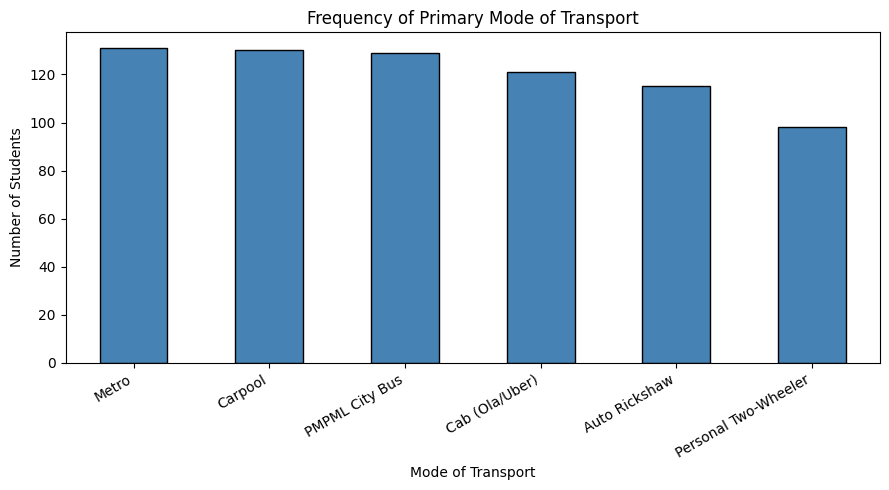

In [49]:
# Bar Chart – Primary Mode of Transport Frequency
plt.figure(figsize=(9,5))
df['Primary_Mode'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Frequency of Primary Mode of Transport')
plt.xlabel('Mode of Transport')
plt.ylabel('Number of Students')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


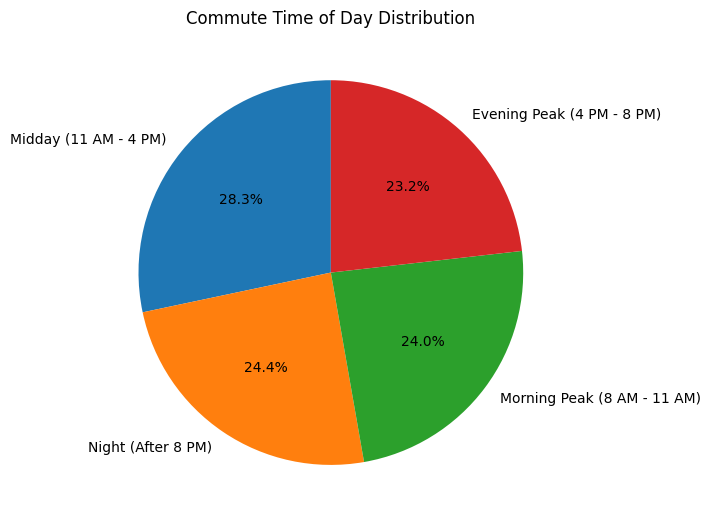

In [50]:
# Pie Chart – Percentage distribution of Time of Day
plt.figure(figsize=(7,7))
df['Time_of_Day'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Commute Time of Day Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()


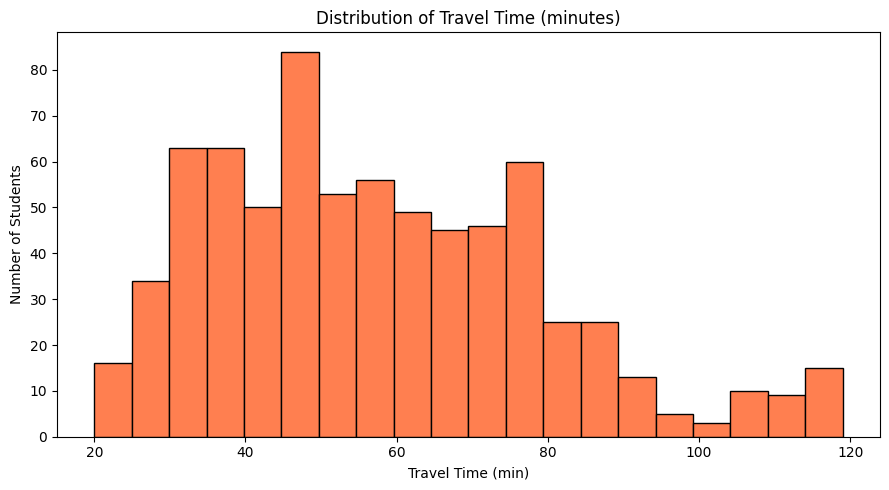

In [51]:
# Histogram – Travel Time Distribution
plt.figure(figsize=(9,5))
plt.hist(df['Travel_Time_min'], bins=20, color='coral', edgecolor='black')
plt.title('Distribution of Travel Time (minutes)')
plt.xlabel('Travel Time (min)')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()


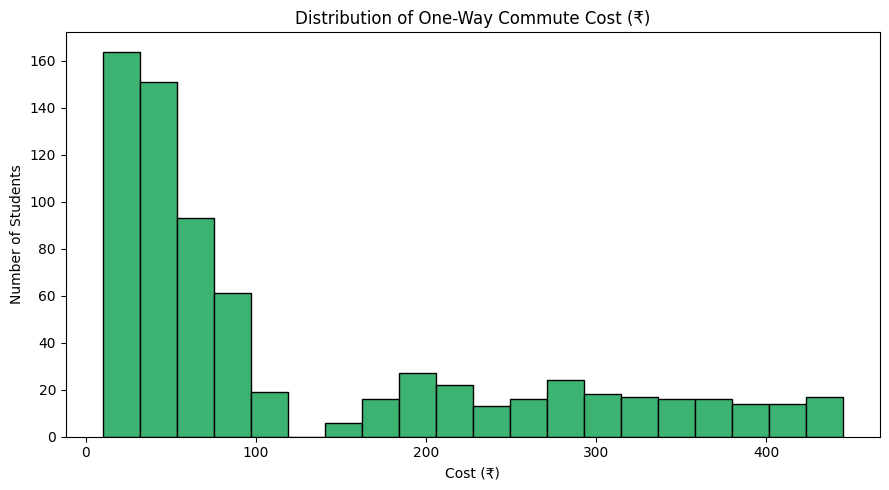

In [52]:
# Histogram – One-Way Cost Distribution
plt.figure(figsize=(9,5))
plt.hist(df['One_Way_Cost_INR'], bins=20, color='mediumseagreen', edgecolor='black')
plt.title('Distribution of One-Way Commute Cost (₹)')
plt.xlabel('Cost (₹)')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()


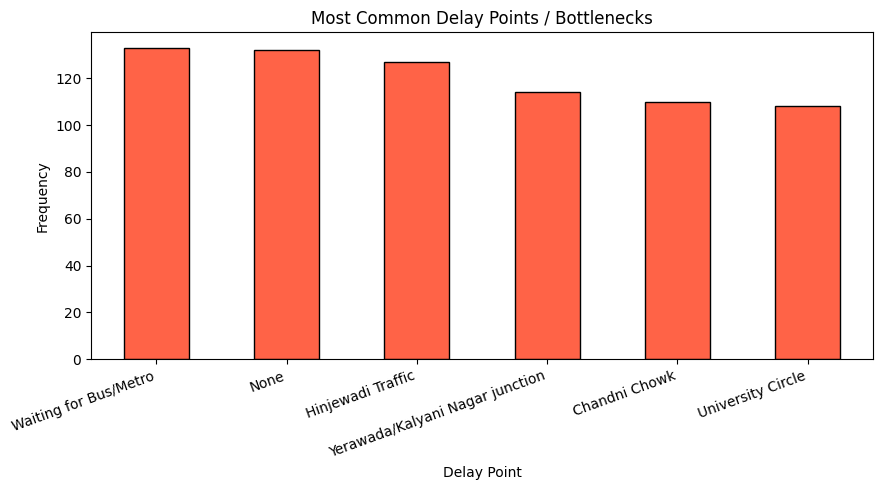

In [53]:
# Bar Chart – Delay Points / Bottlenecks
plt.figure(figsize=(9,5))
df['Delay_Points'].value_counts().plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Most Common Delay Points / Bottlenecks')
plt.xlabel('Delay Point')
plt.ylabel('Frequency')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


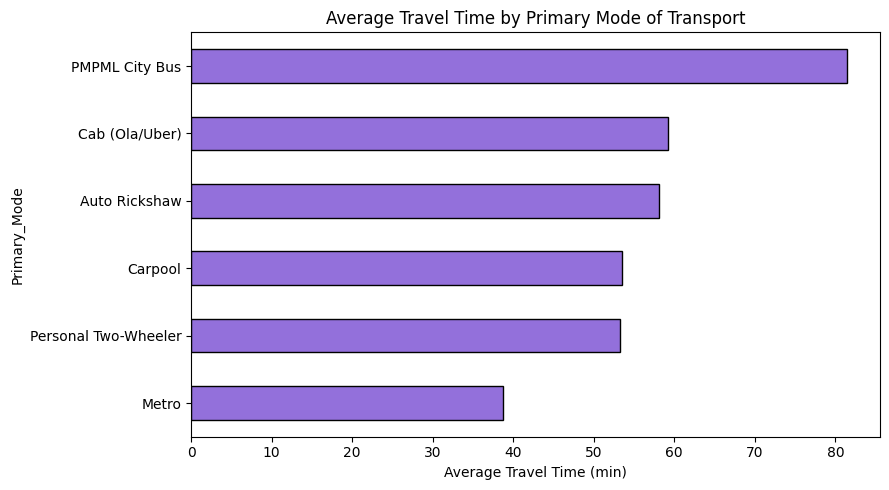

In [54]:
# Bar Chart – Average Travel Time by Primary Mode
plt.figure(figsize=(9,5))
df.groupby('Primary_Mode')['Travel_Time_min'].mean().sort_values().plot(kind='barh', color='mediumpurple', edgecolor='black')
plt.title('Average Travel Time by Primary Mode of Transport')
plt.xlabel('Average Travel Time (min)')
plt.tight_layout()
plt.show()


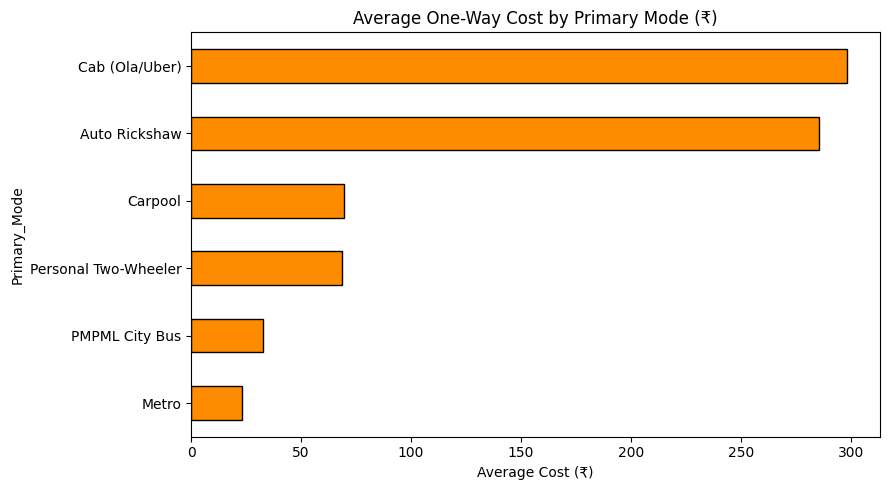

In [55]:
# Bar Chart – Average Cost by Primary Mode
plt.figure(figsize=(9,5))
df.groupby('Primary_Mode')['One_Way_Cost_INR'].mean().sort_values().plot(kind='barh', color='darkorange', edgecolor='black')
plt.title('Average One-Way Cost by Primary Mode (₹)')
plt.xlabel('Average Cost (₹)')
plt.tight_layout()
plt.show()


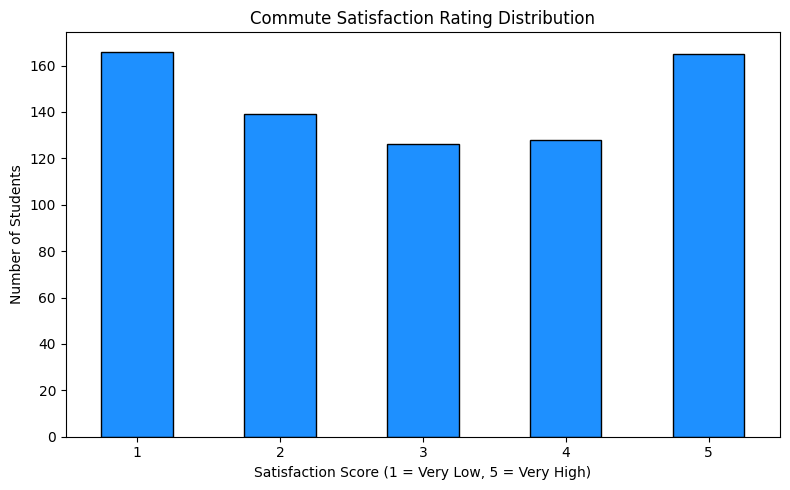

In [56]:
# Bar Chart – Satisfaction Distribution
plt.figure(figsize=(8,5))
df['Satisfaction'].value_counts().sort_index().plot(kind='bar', color='dodgerblue', edgecolor='black')
plt.title('Commute Satisfaction Rating Distribution')
plt.xlabel('Satisfaction Score (1 = Very Low, 5 = Very High)')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Summary of Findings

| Observation | Detail |
|---|---|
| Total Responses | 724 students |
| Starting Points | 7 (Kothrud, Baner, Pashan, Wakad, Shivajinagar, SIT Lavale Campus, Other) |
| Destinations | 6 (Hinjewadi, Kharadi, Pune Station, Swargate, Viman Nagar, Other) |
| Most Used Primary Mode | Metro (18.09%) |
| Fastest Average Mode | Metro (~39 min) |
| Cheapest Average Mode | Metro (~₹23) |
| Most Expensive Mode | Cab (₹298) |
| Biggest Bottleneck | Waiting for Bus/Metro (133 cases) |
| Average Travel Time | ~57 minutes |
| Average One-Way Cost | ~₹127 |
| Missing Values | 132 in Delay_Points (filled with 'None') |
